# My Spotify Data

## Overview
My hypothesis, or driving question, was "what was my top listening day of the week, and what hour of the day on average do I listen to the most music?". <br>

I think that my peak listening hours will either be when I'm getting ready for class or walking there(around noon), or when I'm getting ready for any weekend plans(8:00pm -10:00pm). However, I am usually not in charge of hosting events or running the music, so I think I listen to more music in the early evening compared to late at night(past 9:00pm). As for which day of the week I listen to the most music, I will be absolutely shocked if it is any other day than Friday. I am typically awake the longest on Fridays and listen to music all day; getting ready for the day, at the gym, doing work, and in the shower. 

## Purpose of Analysis
Explain the purpose of the analysis (what questions and motivations drive you?)<br>
I was curious about when during the week, and what time I listen to the most music, so I thought the best way to find this out was to download my data directly. 

## Starting Point and Data Source 
Explain the starting point (what brought you here, are there others you are following?)<br>
Explain the source of the data (where did this data come from, what value does it have?)<br>
<br>
This is where I began with uploading my Spotify data. I donwloaded my data directly from my spotify account, and waited a week to recieve it. I then uploaded one of the 3 JSON files of my "streaming history" to make sure I could access it. My streaming data contains all tracks I've played from May 1st of this year to October 31st of this year. 

In [89]:
import json as js
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# My streaming data
path = r'/Users/ellabenore/Downloads/Spotify Account Data 2/StreamingHistory_music_1.json'

with open(path) as op:
    data1 = js.load(op)

# My 2024 Wrapped
path = r'/Users/ellabenore/Downloads/Spotify Account Data/Wrapped2024.json'

with open(path) as op:
    data2 = js.load(op)

## Data Structure
I have 3 JSON files of my Streaming Data, so I wanted to know if I could combine them all into an object. I asked ChatGPT how to combine my JSON files. The prompt I used was "How do I combine these 3 JSON files in Jupyter Notebook?", and I uploaded my files. ChatGPT showed me how to do this. <br>
I then used pandas dataframes to layout the data structure in a table, and make it easier to convert to scatterplots and bargraphs later. First I found my average listening hour of the day, 

In [67]:
type(data1)

list

In [68]:
type(data2)

dict

In [69]:
data2.keys()

dict_keys(['topArtists', 'topPodcasts', 'topTracks', 'yearlyMetrics', 'musicEvolution'])

In [70]:
df = pd.read_json("/Users/ellabenore/Downloads/Spotify Account Data 2/StreamingHistory_music_1.json")
print(df.head())

            endTime        artistName                 trackName  msPlayed
0  2025-05-01 21:05           Outkast               Ms. Jackson    158990
1  2025-05-01 21:07       BigXthaPlug                Mr.Trouble     74373
2  2025-05-01 21:08             Diplo                      Wish      2066
3  2025-05-01 21:08  Childish Gambino                       Les     86192
4  2025-05-01 21:08       $uicideboy$  Kill Yourself (Part III)      2577


In [71]:
df.to_csv("spotify_streams.csv", index=False)
df = pd.read_csv("spotify_streams.csv")
df.head()

,endTime,artistName,trackName,msPlayed
0,2025-05-01 21:05,Outkast,Ms. Jackson,158990
1,2025-05-01 21:07,BigXthaPlug,Mr.Trouble,74373
2,2025-05-01 21:08,Diplo,Wish,2066
3,2025-05-01 21:08,Childish Gambino,Les,86192
4,2025-05-01 21:08,$uicideboy$,Kill Yourself (Part III),2577


#### Combining JSON Files

In [72]:
files = [
    "/Users/ellabenore/Downloads/Spotify Account Data 2/StreamingHistory_music_0.json",
    "/Users/ellabenore/Downloads/Spotify Account Data 2/StreamingHistory_music_1.json",
    "/Users/ellabenore/Downloads/Spotify Account Data 2/StreamingHistory_music_2.json"
]

dfs = [pd.read_json(f) for f in files]

In [73]:
combined = pd.concat(dfs, ignore_index=True)
combined.head()

,endTime,artistName,trackName,msPlayed
0,2024-11-13 18:41,Deftones,Change (In the House of Flies),181056
1,2024-11-14 02:00,Deftones,Change (In the House of Flies),7895
2,2024-11-14 02:00,Tyla,Water - Remix,4458
3,2024-11-14 02:00,Chance the Rapper,Cocoa Butter Kisses,3134
4,2024-11-14 02:00,DJ Snake,"Taki Taki (feat. Selena Gomez, Ozuna & Cardi B)",5642


### Hour I lsitened to most out of all files

In [74]:
df = pd.concat([pd.read_json(f) for f in files], ignore_index=True)
df.head() ## just to check it's the same 

,endTime,artistName,trackName,msPlayed
0,2024-11-13 18:41,Deftones,Change (In the House of Flies),181056
1,2024-11-14 02:00,Deftones,Change (In the House of Flies),7895
2,2024-11-14 02:00,Tyla,Water - Remix,4458
3,2024-11-14 02:00,Chance the Rapper,Cocoa Butter Kisses,3134
4,2024-11-14 02:00,DJ Snake,"Taki Taki (feat. Selena Gomez, Ozuna & Cardi B)",5642


In [75]:
df['endTime'] = pd.to_datetime(df['endTime'])
df['hour'] = df['endTime'].dt.hour
df['minutesPlayed'] = df['msPlayed'] / 60000 ## I asked ChatGPT because I had no Idea how to do this on my onw in pandas
hourly = df.groupby('hour')['minutesPlayed'].sum()
hourly

hour
0     2538.599600
1     2413.769750
2     1334.119550
3      702.533433
4      538.359550
5      623.708100
6      912.349583
7      614.259733
8      394.527383
9      385.316967
10    1110.738683
11     722.986650
12     870.708017
13    1428.607267
14    1646.127083
15    1971.757700
16    1823.576933
17    1536.141950
18    1378.806483
19    1976.753700
20    2826.521983
21    2955.436950
22    2673.189633
23    2653.806950
Name: minutesPlayed, dtype: float64

In [76]:
peak_hour = hourly.idxmax()
peak_minutes = hourly.max()

print(f"You listen the most at {peak_hour}:00 — about {peak_minutes:.1f} minutes.")

You listen the most at 21:00 — about 2955.4 minutes.


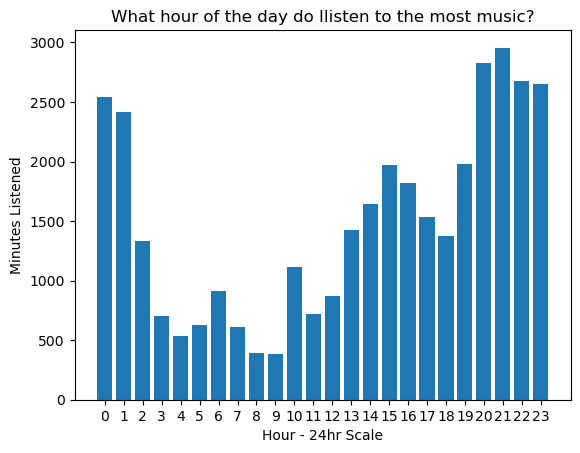

In [78]:
plt.bar(hourly.index, hourly.values)
plt.xlabel("Hour - 24hr Scale")
plt.ylabel("Minutes Listened")
plt.title("What hour of the day do Ilisten to the most music?")
plt.xticks(range(24))
plt.show()

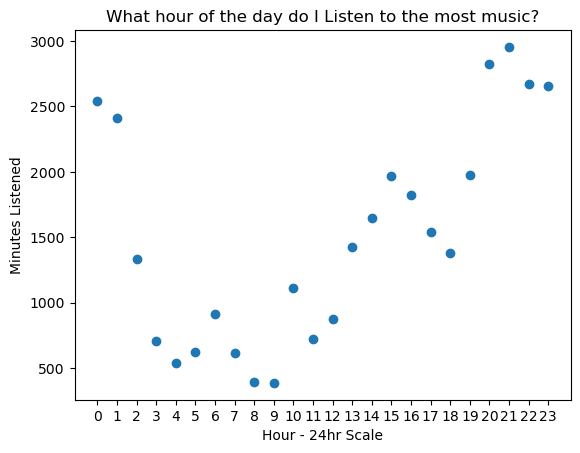

In [80]:
plt.scatter(hourly.index, hourly.values)
plt.xlabel("Hour - 24hr Scale")
plt.ylabel("Minutes Listened")
plt.title("What hour of the day do I Listen to the most music?")
plt.xticks(range(24))
plt.show()

### Density Chart
I used what we did in class for the Penguins dataset

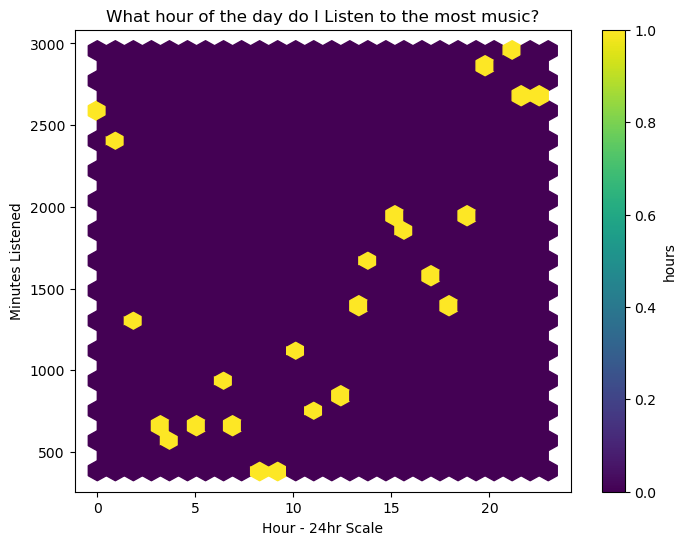

In [91]:
plt.figure(figsize=(8,6))
hb = plt.hexbin(hourly.index, hourly.values, gridsize=25)
plt.xlabel("Hour - 24hr Scale")
plt.ylabel("Minutes Listened")
plt.title("What hour of the day do I Listen to the most music?")
plt.colorbar(label="hours")
plt.show()

## Analysis

<br>
After looking at the Density Chart, it might be better to use this to compare my peak listening days and peak listening hours. It also might be better to look at this in minutes rather than hours. 


## What day of the week do I listen to most

In [82]:
df['weekday'] = df['endTime'].dt.day_name()

weekday_totals = df.groupby('weekday')['minutesPlayed'].sum()
order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
weekday_totals = weekday_totals.reindex(order)
weekday_totals


weekday
Sunday       4134.494833
Monday       3609.055750
Tuesday      5023.190950
Wednesday    4542.666867
Thursday     7123.497150
Friday       6157.389100
Saturday     5442.408983
Name: minutesPlayed, dtype: float64

In [83]:
top_day = weekday_totals.idxmax()
top_minutes = weekday_totals.max()
print(f"My top listening day is {top_day} — about {top_minutes:.1f} minutes.")

My top listening day is Thursday — about 7123.5 minutes.


## Graph My Top Listening Day

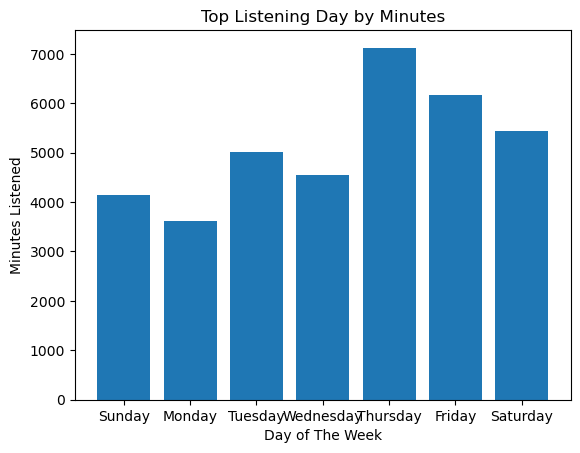

In [84]:
plt.bar(weekday_totals.index, weekday_totals.values)
plt.xlabel("Day of The Week")
plt.ylabel("Minutes Listened")
plt.title("Top Listening Day by Minutes")
plt.show()

## Explanation

All of my days of the week are realitivly close on average, but I was not expecting Thursday to be the highest. I used to travel to visit friends a lot on Thursdays, so that most likely has something to do with it. However, I did not anticipate it all of my days being so close in minutes. I was expecting much larger gaps between the bars for each day. 

## What is my peak day + hour I listen to music?

In [92]:
df['endTime'] = pd.to_datetime(df['endTime'])
df['minutesPlayed'] = df['msPlayed'] / 60000

df['hour'] = df['endTime'].dt.hour
df['dayName'] = df['endTime'].dt.day_name()

In [93]:
pivot = df.pivot_table(
    index='dayName',
    columns='hour',
    values='minutesPlayed',
    aggfunc='sum',
    fill_value=0
)

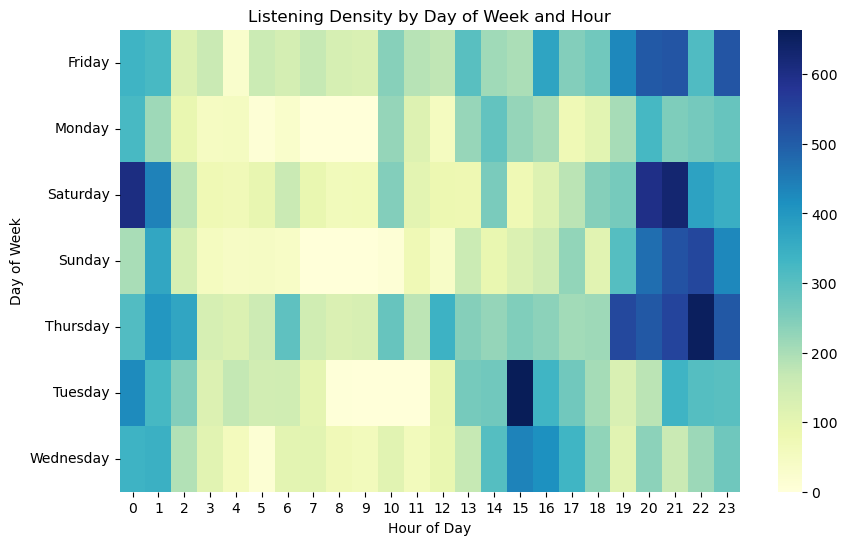

In [94]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Listening Density by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

In [97]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    x=data['hour'],
    y=data['dayNum'],
    weights=data['minutesPlayed'],
    fill=True,
    cmap="magma"
)
plt.yticks(list(day_to_num.values()), list(day_to_num.keys()))
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Listening Density Chart (Hour × Day)")
plt.show()

NameError: name 'data' is not defined

<Figure size 1000x600 with 0 Axes>

## Analysis
I used similar methods that we did in class with the penguins and weather datasets to create different graphs to visually represent my data. I thought this was the best way to show the data in an engaging way. 
<br>
One other limitation I came across while working was my knowledge of combining data. I wanted to create a hex plot, similar to what I did above with my listening hours, for my peak listening day and hour. However, I found it easier to use the other graphs to represent the data. The desity chart above ran with no issues in my Preliminary Draft, and only threw an error when I started adding more Markdown cells. I am unaware why this error is occurring because the code for both graphs is identical. 

# Conclusion
From this report, an audience can take away that I listen to the most music on Thursday and Saturday evenings, and Saturday after midnight. This somewhat supported my hypothesis of my listening habits on Saturdays, but Thursday evenings were an unexpected outcome for peak listening hours. The graphs used through Matplotlib give the audience the clearest visual of my average listening time. The heatmap and Density chart above, both give a comprehensive view of more "listening minutes" on weekends and Thursday evenings. I believe the Density provides the best representation of the data because it's more visually engaging, and audiences can infer that the lower listening times (durring business hours/mornings on weekdays) I am most likely busy or in class. 
<br>
__Limitations, Alternative Approaches, and Possible Next Steps__ <br>
The most prevalent variable that would impact my hypothesis is my job. I did not factor my work schedule into my initial hypothesis at all. I worked about 40 hours a week during the semesters last year, and about 25 a week this semester when this data was collected. This can explain some of the gaps in listening time, and why my data doesn't perfectly support my hypothesis; despite my own percieved experience of listening to music. 